1 - Imports

In [2]:
# ============================================
# 01_EDA - Exploratory Data Analysis
# Customer Behavior Prediction Platform
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries loaded successfully.")

Libraries loaded successfully.


2 - Load Data

In [3]:
# Load cleaned customer-level data
df = pd.read_csv("../data/interim/customer_transactions.csv", parse_dates=["InvoiceDate"])

print(f"Shape              : {df.shape}")
print(f"Date range         : {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
print(f"Unique customers   : {df['Customer_ID'].nunique():,}")
print(f"Unique invoices    : {df['Invoice'].nunique():,}")
print(f"Unique products    : {df['StockCode'].nunique():,}")
df.head()

Shape              : (797885, 10)
Date range         : 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Unique customers   : 5,942
Unique invoices    : 44,876
Unique products    : 4,646


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Is_Return,Invalid_Price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,False,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,False,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False,False


3 - Missing Values & Data Types

In [4]:
print("="*60)
print("MISSING VALUES")
print("="*60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(pd.DataFrame({"Missing": missing, "Percent": missing_pct}))

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(df.dtypes)

MISSING VALUES
               Missing  Percent
Invoice              0      0.0
StockCode            0      0.0
Description          0      0.0
Quantity             0      0.0
InvoiceDate          0      0.0
Price                0      0.0
Customer_ID          0      0.0
Country              0      0.0
Is_Return            0      0.0
Invalid_Price        0      0.0

DATA TYPES
Invoice                     str
StockCode                   str
Description                 str
Quantity                  int64
InvoiceDate      datetime64[us]
Price                   float64
Customer_ID               int64
Country                     str
Is_Return                  bool
Invalid_Price              bool
dtype: object


4 - Numerical Summary

In [5]:
print("="*60)
print("NUMERICAL SUMMARY")
print("="*60)
print(df[["Quantity", "Price"]].describe())

print("\nReturns (Quantity < 0):", (df["Quantity"] < 0).sum())
print("Invalid Price (Price <= 0):", (df["Price"] <= 0).sum())

NUMERICAL SUMMARY
            Quantity          Price
count  797885.000000  797885.000000
mean       12.602980       3.702732
std       191.670371      71.392549
min    -80995.000000       0.000000
25%         2.000000       1.250000
50%         5.000000       1.950000
75%        12.000000       3.750000
max     80995.000000   38970.000000

Returns (Quantity < 0): 18390
Invalid Price (Price <= 0): 70


5 - Top Countries

In [6]:
print("="*60)
print("TOP 10 COUNTRIES BY TRANSACTIONS")
print("="*60)
print(df["Country"].value_counts().head(10))

TOP 10 COUNTRIES BY TRANSACTIONS
Country
United Kingdom    716115
Germany            17339
EIRE               16014
France             13897
Netherlands         5137
Spain               3754
Belgium             3110
Switzerland         3058
Portugal            2414
Australia           1890
Name: count, dtype: int64


6 – Returns Analysis

In [7]:
print("="*60)
print("RETURNS ANALYSIS")
print("="*60)

returns = df[df["Is_Return"] == True]
print(f"Total return transactions : {len(returns):,}")
print(f"Percentage of returns     : {len(returns)/len(df)*100:.2f}%")
print(f"Unique customers who returned : {returns['Customer_ID'].nunique():,}")

print("\nTop 10 products returned:")
print(returns["Description"].value_counts().head(10))

RETURNS ANALYSIS
Total return transactions : 18,390
Percentage of returns     : 2.30%
Unique customers who returned : 2,572

Top 10 products returned:
Description
Manual                                397
REGENCY CAKESTAND 3 TIER              341
BAKING SET 9 PIECE RETROSPOT          208
STRAWBERRY CERAMIC TRINKET BOX        181
POSTAGE                               180
Discount                              165
WHITE HANGING HEART T-LIGHT HOLDER    133
WHITE CHERRY LIGHTS                   119
RED RETROSPOT CAKE STAND              106
PINK CHERRY LIGHTS                     86
Name: count, dtype: int64


7 – Monthly Transaction Trend

MONTHLY TRANSACTION TREND
YearMonth
2009-12    31276
2010-01    22122
2010-02    23578
2010-03    32592
2010-04    27429
2010-05    29191
2010-06    31447
2010-07    27357
2010-08    26577
2010-09    34911
2010-10    49719
2010-11    60081
2010-12    26354
2011-01    21670
2011-02    20138
2011-03    27516
2011-04    22988
2011-05    28661
2011-06    27576
2011-07    27256
2011-08    27444
2011-09    40459
2011-10    49928
2011-11    64232
2011-12    17383
Freq: M, dtype: int64


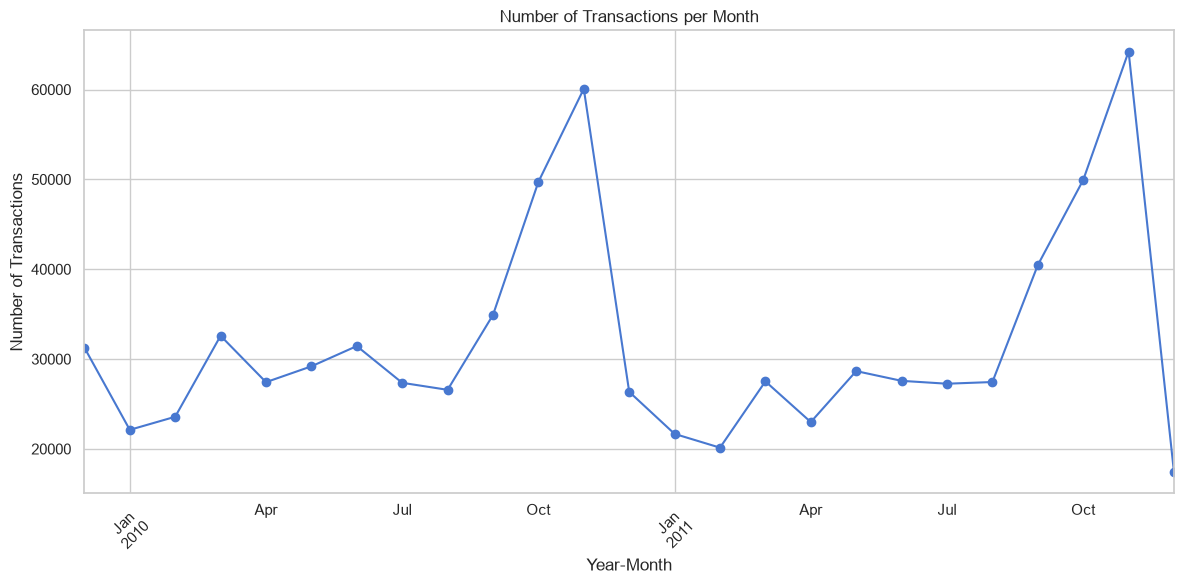

In [8]:
print("="*60)
print("MONTHLY TRANSACTION TREND")
print("="*60)

df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")
monthly = df.groupby("YearMonth").size()
print(monthly)

# Simple plot
monthly.plot(kind="line", marker="o", title="Number of Transactions per Month")
plt.xlabel("Year-Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

8 – Basic Customer Level Preview

In [10]:
print("="*60)
print("CUSTOMER-LEVEL PREVIEW (Top 10 by number of transactions)")
print("="*60)

# Create a proper revenue column first
df["Revenue"] = df["Quantity"] * df["Price"]

customer_summary = df.groupby("Customer_ID").agg(
    n_transactions = ("Invoice", "count"),
    n_invoices     = ("Invoice", "nunique"),
    total_quantity = ("Quantity", "sum"),
    total_revenue  = ("Revenue", "sum"),
    first_purchase = ("InvoiceDate", "min"),
    last_purchase  = ("InvoiceDate", "max")
).sort_values("n_transactions", ascending=False)

print(customer_summary.head(10).round(2))

CUSTOMER-LEVEL PREVIEW (Top 10 by number of transactions)
             n_transactions  n_invoices  total_quantity  total_revenue  \
Customer_ID                                                              
17841                 12638         289           36151       67186.87   
14911                 11444         510          141750      265757.91   
12748                  6662         365           35086       46933.33   
14606                  6500         259           14884       29197.59   
14096                  5128          34           16335       57120.91   
15311                  4579         270           68882      111739.36   
14156                  4118         202          162245      296063.44   
14646                  3890         164          365220      523342.07   
13089                  3391         247           57946      109893.24   
16549                  3098          37            7082       12759.25   

                 first_purchase       last_purchase  

C:\Users\Robin\AppData\Local\Temp\ipykernel_9668\1325651289.py:17: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(customer_summary.head(10).round(2))


9 – Revenue Overview

In [11]:
print("="*60)
print("REVENUE OVERVIEW")
print("="*60)

print(f"Total Revenue          : £{df['Revenue'].sum():,.2f}")
print(f"Average Order Value    : £{df.groupby('Invoice')['Revenue'].sum().mean():.2f}")
print(f"Median Order Value     : £{df.groupby('Invoice')['Revenue'].sum().median():.2f}")

print("\nRevenue by Return vs Normal:")
print(df.groupby("Is_Return")["Revenue"].sum())

REVENUE OVERVIEW
Total Revenue          : £16,289,991.29
Average Order Value    : £363.00
Median Order Value     : £235.69

Revenue by Return vs Normal:
Is_Return
False    1.737480e+07
True    -1.084813e+06
Name: Revenue, dtype: float64


10 – Written Hypotheses (Required by PRD)

In [13]:
print("="*60)
print("HYPOTHESES FOR MODELING STAGE")
print("="*60)

hypotheses = """
Based on the Exploratory Data Analysis, here are the key hypotheses we will test in the modeling phase:

1. Recency Hypothesis:
   Customers who have not purchased recently (high Recency) are significantly more likely to churn.

2. Frequency Hypothesis:
   Customers with low purchase frequency are at higher risk of churn compared to habitual buyers.

3. Monetary Hypothesis:
   High-value customers (high total revenue) may still churn, but they should be prioritized for retention because of their lifetime value.

4. Returns Hypothesis:
   Customers with a higher return rate are more likely to churn (returns signal dissatisfaction).

5. Seasonal / Country Hypothesis:
   Purchase behavior and churn risk differ by country and by season (especially around November–December peaks).

6. Engagement Trend Hypothesis:
   Customers whose purchase frequency is declining over time are more likely to churn than those with stable or increasing frequency.

These hypotheses will guide Feature Engineering (RFM, CLV, return rate, trends) and model evaluation.
"""

print(hypotheses)

HYPOTHESES FOR MODELING STAGE

Based on the Exploratory Data Analysis, here are the key hypotheses we will test in the modeling phase:

1. Recency Hypothesis:
   Customers who have not purchased recently (high Recency) are significantly more likely to churn.

2. Frequency Hypothesis:
   Customers with low purchase frequency are at higher risk of churn compared to habitual buyers.

3. Monetary Hypothesis:
   High-value customers (high total revenue) may still churn, but they should be prioritized for retention because of their lifetime value.

4. Returns Hypothesis:
   Customers with a higher return rate are more likely to churn (returns signal dissatisfaction).

5. Seasonal / Country Hypothesis:
   Purchase behavior and churn risk differ by country and by season (especially around November–December peaks).

6. Engagement Trend Hypothesis:
   Customers whose purchase frequency is declining over time are more likely to churn than those with stable or increasing frequency.

These hypothes